<a href="https://colab.research.google.com/github/Harshini-Suresha/Plant_classification/blob/main/Cast_iron%2C_Date_Palm%2C_ArecaNut%2C_Bird_of_Paradise_and_Monstera_deliciosa_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***The information of each code snippet is one below the other.***

# **Python Libraries**

1.   **tensorflow:**  imports the TensorFlow library
   
2. **Import matplotlib.pyplot as plt:** Imports the Matplotlib library for plotting, aliased as plt.

3. **import numpy as np:** Imports the NumPy library for numerical operations, aliased as np.






In [2]:
import tensorflow as tf

The code import tensorflow as tf imports the TensorFlow library, a powerful tool for numerical computation and machine learning, and assigns it the alias tf. This common practice in Python allows you to use the library's functions and classes by simply typing tf followed by a dot (.), improving code readability and efficiency. For example, you can create a TensorFlow constant using tf.constant() instead of writing out tensorflow.constant(

In [3]:
# connect to google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


The code cell from google.colab import drive; drive.mount('/content/gdrive') is used in Google Colab to connect your notebook to your Google Drive. It first imports the necessary drive module and then uses drive.mount() to establish a connection to your Drive at the specified path /content/gdrive. This prompts an authentication process, requiring you to grant Colab access to your Drive. After completing the authentication you can access your files and folders stored in your Drive within the colab environment using the mounted path.

In [4]:
#print tensorflow version
print(tf.__version__)

2.15.1


In [5]:
#Separate your data into training and validation sets and specify the path.
dataset=tf.keras.preprocessing.image_dataset_from_directory(
        "/content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model") #load images from a directory, automatically inferring labels from subdirectories.
ds_train = tf.keras.preprocessing.image_dataset_from_directory(
        "/content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model", #Path to the your dataset in Google drive
        validation_split=0.2,
        subset="training",
        seed=123)
ds_validation = tf.keras.preprocessing.image_dataset_from_directory(
        "/content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model",
        validation_split=0.2,
        subset="validation",
        seed=123)

Found 1285 files belonging to 5 classes.
Found 1285 files belonging to 5 classes.
Using 1028 files for training.
Found 1285 files belonging to 5 classes.
Using 257 files for validation.


This code is using TensorFlow's Keras API to load image data from a directory and split it into training and validation sets. It first defines the path to your image dataset, located in your Google Drive.

Then, it uses tf.keras.preprocessing.image_dataset_from_directory to create three datasets: dataset, ds_train, and ds_validation. dataset loads all images, while ds_train and ds_validation split the data into training and validation sets with a split ratio of 80% and 20%, respectively, using validation_split, subset, and a fixed seed for reproducibility. This separation is crucial for evaluating the performance of your machine learning model during training.

**Why Split Data?** In machine learning, it's crucial to split your data into training and validation sets. The training set is used to train your model, and the validation set is used to evaluate how well your model is performing on unseen data. This helps prevent overfitting, where your model learns the training data too well and doesn't generalize well to new data.
tf.data.Dataset: The use of tf.data.Dataset provides efficient data loading and preprocessing capabilities, making it easier to work with large datasets in TensorFlow.

In [6]:
# define the batch size and print the image labels
import tensorflow_datasets as tfds
batch_size = 64 # model will look at 64 images at a time before updating its internal parameters
dataset_name = dataset
class_names = dataset.class_names #extracts the names of the different image categories (or classes) from the dataset and stores them in a variable called class_names
print(class_names)

['ArecaNut', 'Bird of paradise', 'Cast iron', 'Date Palm', 'Monstera deliciosa']


Primarily focuses on setting up a batch size for training and getting the names of the image classes in the dataset.

In [7]:
val_batches = tf.data.experimental.cardinality(ds_validation) #tells you how many batches of data are present in your validation set.
test_dataset = ds_validation.take(val_batches // 5) #The resulting dataset containing the first 20% of the validation data is assigned to the test_dataset variable.
validation_dataset = ds_validation.skip(val_batches // 5) #The resulting dataset, containing the remaining 80% of the validation data (after skipping the first 20%), is assigned to the validation_dataset variable.


1. tf.data.experimental.cardinality(ds_validation): This function is used to determine the number of batches in the ds_validation dataset.

val_batches = ...: The result (number of batches) is then stored in the variable val_batches.

2. ds_validation.take(val_batches // 5): This part creates a new dataset called test_dataset by taking a portion of the ds_validation dataset.

val_batches // 5: This calculates the number of batches to take. It divides the total number of batches in ds_validation by 5 and uses the integer part of the result (using floor division //). This essentially takes the first 20% of the validation dataset for testing.

3. ds_validation.skip(val_batches // 5): This creates another new dataset called validation_dataset. It does this by skipping a portion of the ds_validation dataset.

val_batches // 5: Similar to before, this calculates how many batches to skip (which is the same number of batches taken for the test set, i.e., 20% of the validation dataset).



1. test_dataset: Contains the first 20% of the original ds_validation data and is used for final model evaluation after training.

2. validation_dataset: Contains the remaining 80% of the original ds_validation data and is used during training to monitor the model's performance and prevent overfitting.




In [8]:
#To prepare your data for neural analysis, resize the images and unify your data.
#Standardalising the data makes it easier for the model to learn data

size = (512, 512)   #defines a tuple named size that stores the desired width and height for the resized images, which is 512 pixels for both.
ds_train = ds_train.map(lambda image, label: (tf.image.resize(image, size), label))     #applies a function to each element of the ds_train dataset.
ds_val= ds_validation.map(lambda image, label: (tf.image.resize(image, size), label))   #same resizing operation for the validation dataset (ds_validation) and stores the result in ds_val.
ds_test = test_dataset.map(lambda image, label: (tf.image.resize(image, size), label))  #performs the same resizing for the test dataset (test_dataset) and stores the result in ds_test.


**The code iterates through each image in the training, validation, and test datasets, resizes them to 512x512 pixels using tf.image.resize, and keeps the original labels associated with the images.**

**lambda image, label: (tf.image.resize(image, size), label):** This is an anonymous function (lambda function) that takes an image and its label as input.

**tf.image.resize(image, size):** This uses TensorFlow's tf.image.resize function to resize the image to the dimensions specified in the size tuple.
The lambda function returns the resized image and its original label.
The result of applying this function to all elements of ds_train is assigned back to ds_train, effectively replacing the original images with the resized ones.

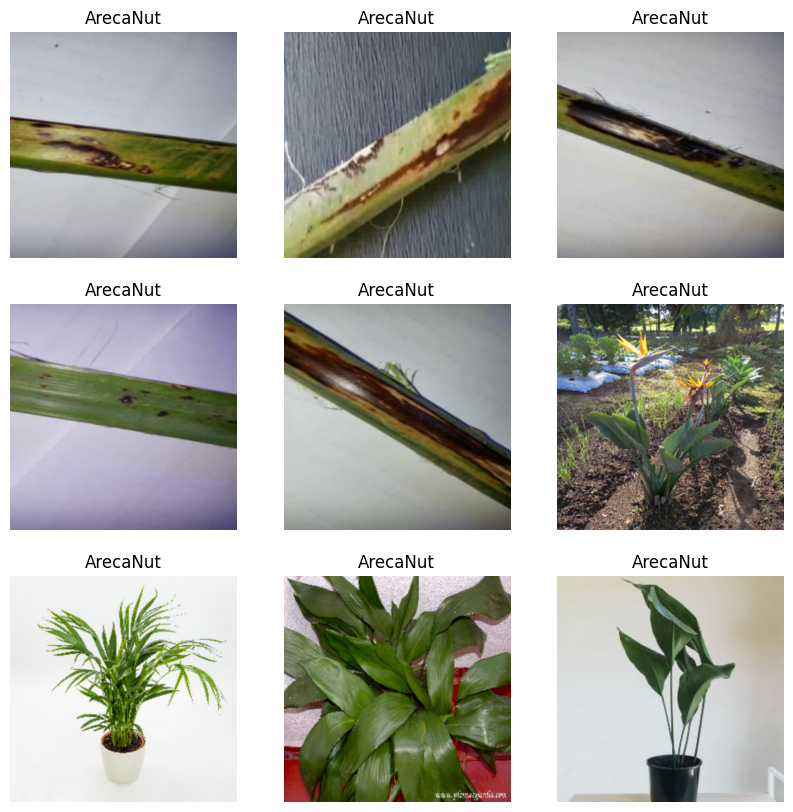

In [9]:
# Display the first 9 images
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))  #Creates a Matplotlib figure with a size of 10x10 inches to display the images.
for images, labels in ds_train.take(1):
  for i in range (9):
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))

    # Get the class index from the label
    class_index = np.argmax(labels[i].numpy())  # Assuming labels are one-hot encoded
    #class_index = labels[i].numpy() # If labels are not one-hot encoded and are integers

    plt.title(class_names[class_index])  # Use the class index to get the class name
    plt.axis("off")

**class_index = np.argmax(labels[i].numpy()):** This line extracts the class index from the label.
It assumes that labels are one-hot encoded (a common practice in classification).

**np.argmax()** finds the index of the maximum value in the one-hot encoded label, which corresponds to the predicted class.

The commented line **#class_index = labels[i].numpy()** would be used if the labels were not one-hot encoded and were directly represented as integers.

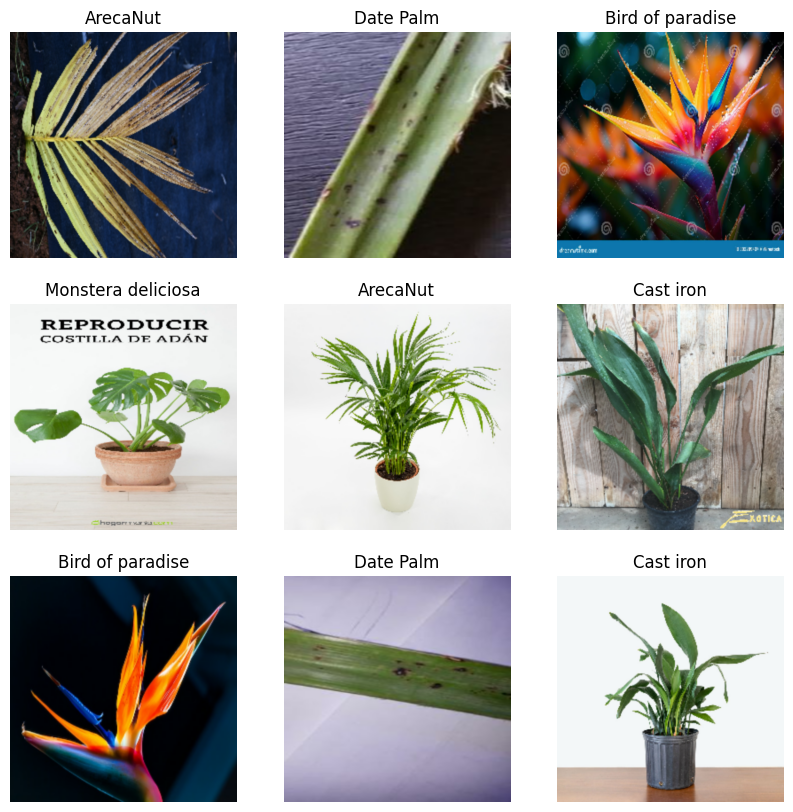

In [10]:
# display the first 9 images
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10)) #Creates a Matplotlib figure with a size of 10x10 inches to display the images.
for images, labels in ds_train.take(1):   #this loop iterates through the first batch of data obtained from ds_train.take(1). It extracts the images and their corresponding labels.
  for i in range(9):         #inner loop iterates 9 times to process the first 9 images in the batch.
    ax = plt.subplot(3, 3, i + 1)    #Creates a subplot within the figure. 3, 3 specifies a 3x3 grid of subplots, and i + 1 determines the position of the current subplot.
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])    #Sets the title of the subplot to the class name corresponding to the predicted class index. It uses the class_names list to get the name.
    plt.axis("off")  # Hides the axes of the subplot for cleaner visualization.

**plt.imshow(images[i].numpy().astype("uint8")):** Displays the current image using plt.imshow().

**images[i].numpy():** Converts the TensorFlow tensor representing the image to a NumPy array.

**.astype("uint8"):** Converts the data type of the image array to uint8 (unsigned 8-bit integer), which is a common format for images.

In [11]:
#do further preprocessing to increase the instances of images
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

image = Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(height_factor=(-0.2,-0.3),width_factor=(-0.2,-0.3),interpolation='bilinear'),
        layers.RandomContrast(factor=0.1),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    ],
    name="image",
)





1.   **from tensorflow.keras.models import Sequential:** Imports the Sequential class from Keras. The Sequential model is a linear stack of layers, where you can add layers one after the other.

2.   **from tensorflow.keras import layers:** Imports the layers module from Keras, which contains various layer types like RandomFlip, RandomRotation, etc.



**A larger pad value creates more space between the title and the image, preventing overlap.
A smaller pad value brings the title closer to the image, potentially causing overlap.**

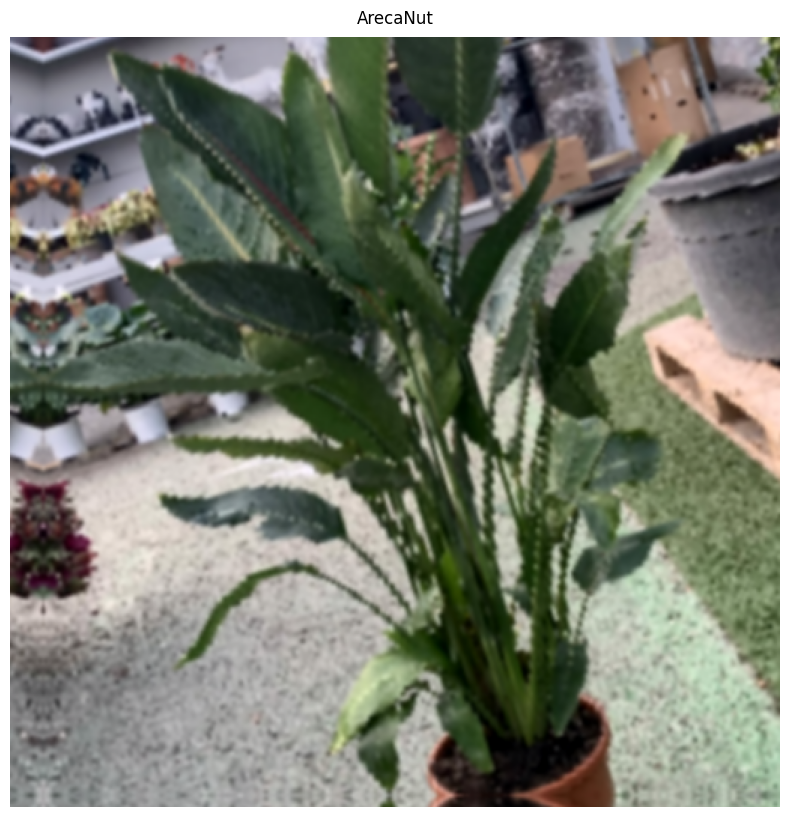

In [12]:
import numpy as np

for images, labels in ds_train.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    def f(x):
      return int(x)
    f2 = np.vectorize(f)
    for i in range(9):
        augmented_image = image(
            tf.expand_dims(first_image, 0), training=True
        )
        plt.imshow(augmented_image[0].numpy().astype("int32"))
        plt.title(f2(labels[0]))
        plt.title(class_names[class_index], pad=10)
        plt.axis("off")



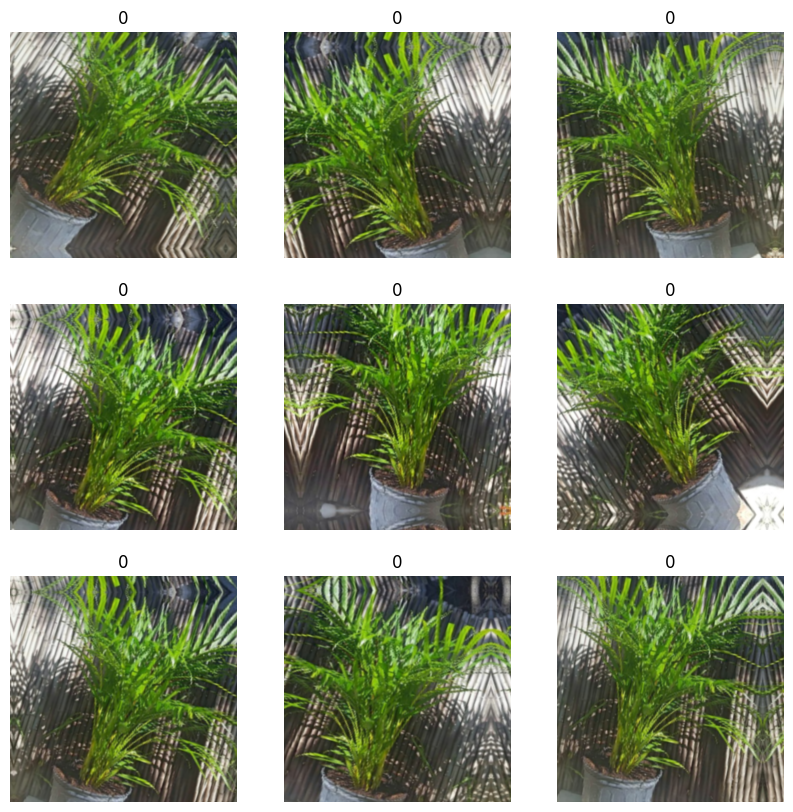

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

#define the augmentation model
image_augmentation = Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(height_factor=(-0.2,-0.3),width_factor=(-0.2,-0.3),interpolation='bilinear'),
        layers.RandomContrast(factor=0.1),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    ],
    name="image",
)

# Defines helper functions if not already done so
def f(x):
  return np.int32(x)
f2 = np.vectorize(f)

for images, labels in ds_train.take(1):
  plt.figure(figsize=(10, 10))
  for i in range(9):
      #Get an image from the dataset
      first_image = images[0]
      ax = plt.subplot(3, 3, i + 1)
      #Augment the image using the sequential model
      augmented_image = image_augmentation(tf.expand_dims(first_image, 0), training=True)
      plt.imshow(augmented_image[0].numpy().astype("int32"))
      plt.title(f2(labels[0]))
      plt.axis("off")

In [14]:
NUM_CLASSES=len(class_names)

In [15]:
# !pip uninstall tensorflow-addons
# !pip uninstall typeguard

In [16]:
# One-hot / categorical encoding
def input_preprocess(image, label):
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label


ds_train = ds_train.map(
    input_preprocess, num_parallel_calls=tf.data.AUTOTUNE
)

ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(input_preprocess)
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.map(input_preprocess)
ds_val = ds_val.prefetch(tf.data.AUTOTUNE)


In [17]:
# Define the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(512, 512, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=5, activation='softmax')
])


In [18]:
!pip install tensorflow-addons[tensorflow]

In [19]:
!pip install tensorflow-addons
import tensorflow_addons as tfa

/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [20]:
#Compile the model
model.compile(
    optimizer='adam',
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.Precision(name='precision'),
             tfa.metrics.F1Score(name='f1_score', num_classes=5),
            ]
)

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 510, 510, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 255, 255, 32)      0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 255, 255, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 253, 253, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 126, 126, 64)      0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 126, 126, 64)      0

In [22]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
es = EarlyStopping(monitor='val_accuracy', min_delta = 0.01 , verbose=1, patience=10)

model_cp =ModelCheckpoint(filepath = "/content/gdrive/MyDrive/Weights/myCNN_modelv1.H5 ", monitor = "val_accuracy",
                          save_best_only = True,
                          save_weights_only = False,
                          verbose = 1)

In [24]:
import os
import PIL
from PIL import Image
source_dir=r'/content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model'
source_list=os.listdir (source_dir)
for file in source_list:
    fpath=os.path.join(source_dir, file)
    try:
        img=Image.open(fpath)
        shape=img.size
        if file.endswith('jpeg') or file.endswith( 'jpg'):
            pass
        else:
            print ('file ', fpath, ' has an extension other than jpg or jpeg')
    except:
        print ('file ', fpath, ' is an invalid image file')
print ('***** process completed *****')

file  /content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/ArecaNut  is an invalid image file
file  /content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/Cast iron  is an invalid image file
file  /content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/Date Palm  is an invalid image file
file  /content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/Bird of paradise  is an invalid image file
file  /content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/Monstera deliciosa  is an invalid image file
***** process completed *****


In [25]:
# train the model
epochs = 3
hist = model.fit(ds_train, epochs=epochs, validation_data=ds_val, callbacks=[model_cp, es], batch_size=64, verbose=1)

Epoch 1/3
33/33 [==============================] - ETA: 0s - loss: 5432.9604 - accuracy: 0.2208 - recall: 0.1702 - precision: 0.2318 - f1_score: 0.1989 
Epoch 1: val_accuracy improved from -inf to 0.42802, saving model to /content/gdrive/MyDrive/Weights/myCNN_modelv1.H5 
33/33 [==============================] - 714s 21s/step - loss: 5432.9604 - accuracy: 0.2208 - recall: 0.1702 - precision: 0.2318 - f1_score: 0.1989 - val_loss: 1.5997 - val_accuracy: 0.4280 - val_recall: 0.0039 - val_precision: 1.0000 - val_f1_score: 0.2555
Epoch 2/3
33/33 [==============================] - ETA: 0s - loss: 1.5855 - accuracy: 0.3589 - recall: 0.0302 - precision: 0.6327 - f1_score: 0.2934 
Epoch 2: val_accuracy did not improve from 0.42802
33/33 [==============================] - 771s 22s/step - loss: 1.5855 - accuracy: 0.3589 - recall: 0.0302 - precision: 0.6327 - f1_score: 0.2934 - val_loss: 1.5736 - val_accuracy: 0.3774 - val_recall: 0.0039 - val_precision: 1.0000 - val_f1_score: 0.1725
Epoch 3/3
33/3

In [26]:
# Visualize the training and validation curves
import matplotlib.pyplot as plt


def plot_hist(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()

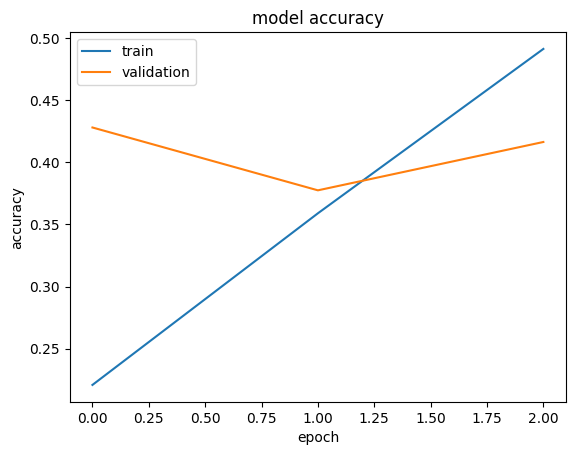

In [27]:
plot_hist(hist)


In [28]:
test=ds_test
from tensorflow_addons.metrics import cohens_kappa
loss, accuracy, precision, recall, f1_score =  model.evaluate(test)
print('Test accuracy :', accuracy)
print('Precision :', precision)
print('recall :', recall)
print('f1_score :', f1_score)

1/1 [==============================] - 9s 9s/step - loss: 1.4526 - accuracy: 0.5312 - recall: 0.0312 - precision: 1.0000 - f1_score: 0.2903
Test accuracy : 0.53125
Precision : 0.03125
recall : 1.0
f1_score : [0.         0.3333333  0.40000004 0.71794873 0.        ]


# Heatmap

The heatmap visualizes the confusion matrix, where each cell represents the count of instances where the model predicted a specific class (x-axis) when the actual class was another (y-axis).
Darker colors in the heatmap indicate higher values (more predictions).
Diagonal cells show correct predictions, while off-diagonal cells show misclassifications.



In [29]:
!pip install seaborn scikit-learn

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [33]:
#Get predictions
predictions = model.predict(test)
predicted_labels = np.argmax(predictions, axis=1)


1/1 [==============================] - 13s 13s/step


In [34]:
true_labels = []
for _, label in test:  # Iterate through the test dataset
    true_labels.extend(np.argmax(label.numpy(), axis=1))  # Convert one-hot to class indices
true_labels = np.array(true_labels)

In [35]:
cm = confusion_matrix(true_labels, predicted_labels)

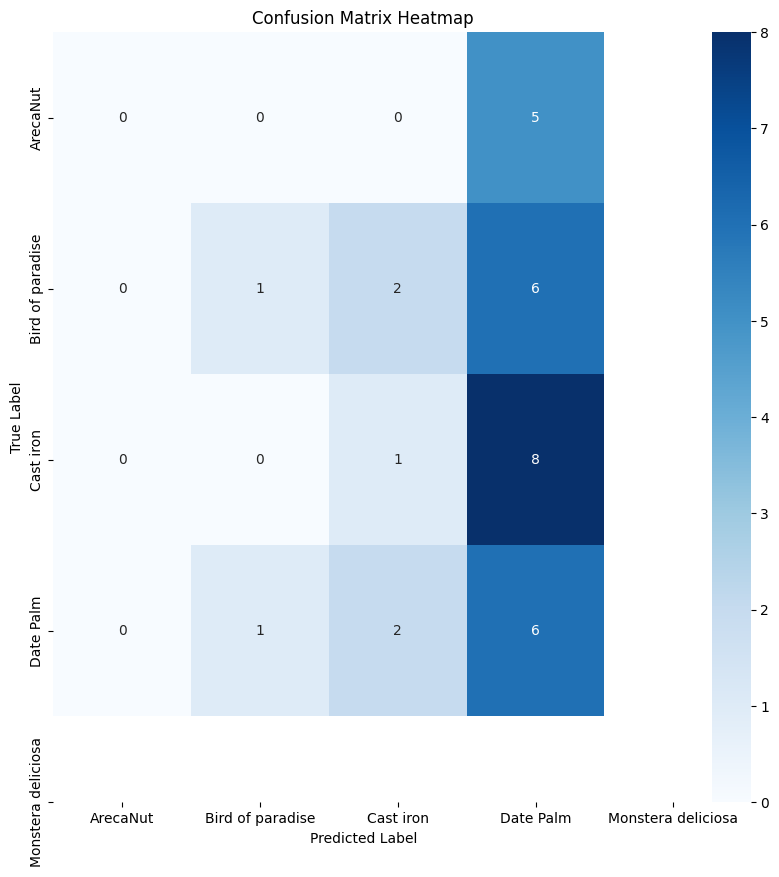

In [36]:
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

# Why heatmaps are used in plant image classification models?



1.   **Identifying Important Regions:** Heatmaps can highlight the areas of an image that the model focuses on when making predictions. This helps understand which features are most influential in the classification process. For plant images, it could reveal whether the model is correctly focusing on leaves, stems, flowers, or other relevant parts.

2.  **Debugging and Improvement:** By visualizing attention, you can identify potential biases or shortcomings in the model. For instance, if the heatmap shows the model focusing on irrelevant background elements, you can adjust your training data or model architecture to improve performance.

3. **Analyzing Errors:** When a model makes an incorrect prediction, a heatmap can reveal which parts of the image led to the mistake. This helps in understanding the reasons behind misclassifications and refining the model accordingly.

4. **Improving Data Quality:** Heatmaps can uncover issues with the training data, such as mislabeled images or inconsistencies in annotations. This information is valuable for improving data quality and model training.

5. **Testing Generalization:** By observing heatmaps for various images, you can assess how well the model generalizes to different plant species, lighting conditions, or viewpoints.

6. **Identifying Limitations:** Heatmaps can expose scenarios where the model struggles, such as when presented with occluded or distorted plant images. This knowledge helps in understanding the model's limitations and potential areas for improvement.

7. **Explaining Predictions:** Heatmaps provide a visual explanation of the model's decision-making process, making it more interpretable and transparent. This is crucial for building trust and understanding how the model arrives at its predictions.

8. **Communicating Results:** Heatmaps are a powerful tool for communicating model insights to stakeholders, such as researchers, farmers, or plant enthusiasts. They offer a clear and intuitive way to visualize the model's behavior and its focus on specific features.

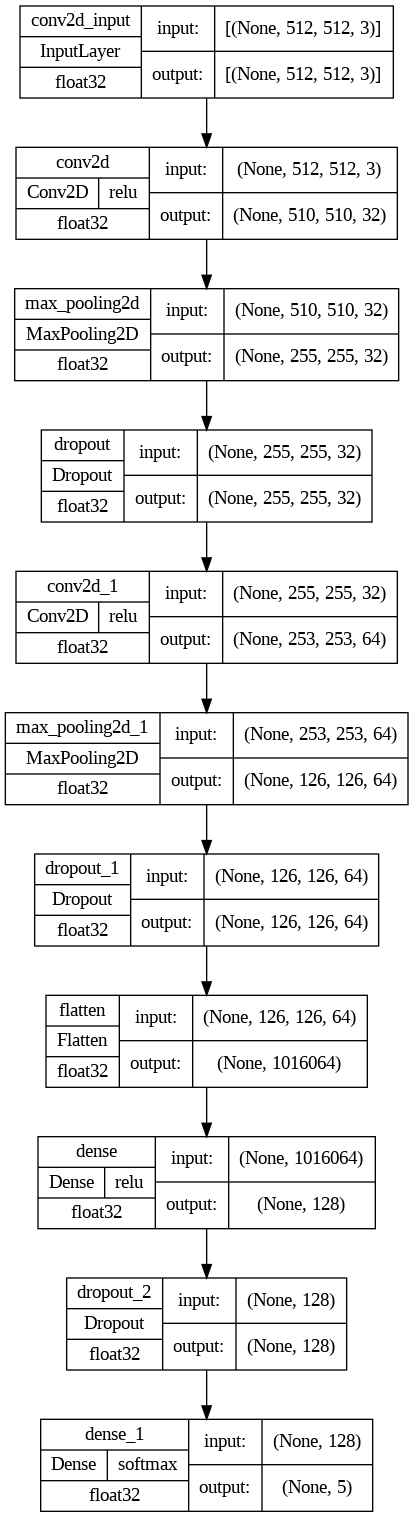

In [38]:
import tensorflow as tf
from tensorflow import keras  # Import keras from tensorflow

keras.utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    show_layer_activations=True
)

In [41]:
# Retrieve class names from the original dataset object (dataset)
class_names = dataset.class_names
class_indices = {class_name: index for index, class_name in enumerate(class_names)}
print(class_indices)

{'ArecaNut': 0, 'Bird of paradise': 1, 'Cast iron': 2, 'Date Palm': 3, 'Monstera deliciosa': 4}


In [47]:
from tensorflow.keras.models import load_model
model.save('Model.h5')

# load model
savedModel=load_model('Model.h5')


/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1/1 [==============================] - 0s 175ms/step
[[0.2199114  0.2004108  0.18882182 0.19421795 0.19663808]]


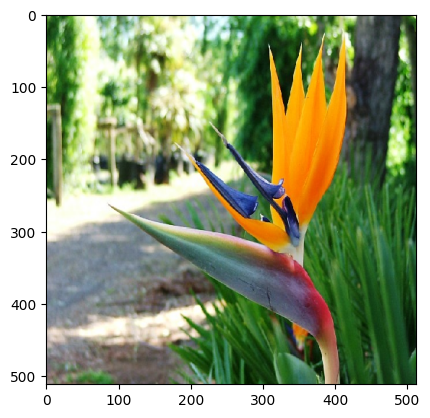

In [55]:
from keras.preprocessing import image

#Creating list for mapping
list_ = ['ArecaNut','Bird of paradise','Cast iron','Date Palm', 'Monstera deliciosa']

#Input image
test_image = image.load_img('/content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/Bird of paradise/Copy of Copy of 102.jpg',target_size=(512,512))

#For show image
plt.imshow(test_image)
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image,axis=0)

# Result array
result = savedModel.predict(test_image)
print(result)

#Mapping result array with the main name list
i=0
for i in range(len(result[0])):
  if(result[0][i]==1):
    print(list_[i])
    break


1/1 [==============================] - 0s 208ms/step
[[0.20848145 0.19146173 0.18000685 0.2380769  0.18197311]]


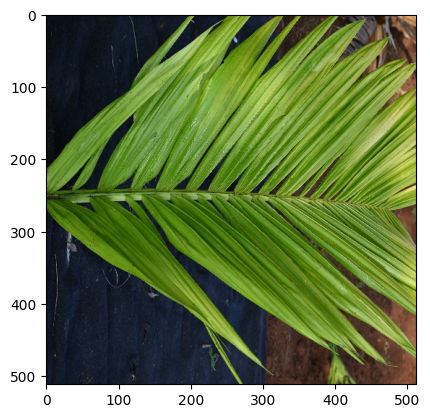

In [54]:
#Input image
test_image = image.load_img('/content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/ArecaNut/Copy of DSC_7540.jpg',target_size=(512,512))

#For show image
plt.imshow(test_image)
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image,axis=0)

# Result array
result = savedModel.predict(test_image)
print(result)

#Mapping result array with the main name list
i=0
for i in range(len(result[0])):
  if(result[0][i]==1):
    print(list_[i])
    break


1/1 [==============================] - 0s 193ms/step
[[0.1916658  0.16215567 0.23219231 0.23528776 0.17869844]]


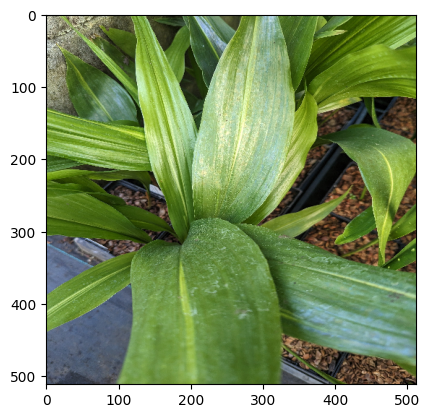

In [57]:
from keras.preprocessing import image

#Creating list for mapping
list_ = ['Daisy','Danelion','Rose','sunflower', 'tulip']

#Input image
test_image = image.load_img('/content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/Cast iron/Copy of Copy of 101.jpg',target_size=(512,512))

#For show image
plt.imshow(test_image)
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image,axis=0)

# Result array
result = savedModel.predict(test_image)
print(result)

#Mapping result array with the main name list
i=0
for i in range(len(result[0])):
  if(result[0][i]==1):
    print(list_[i])
    break


1/1 [==============================] - 0s 171ms/step
[[0.20882492 0.1725192  0.17800105 0.25518826 0.18546654]]


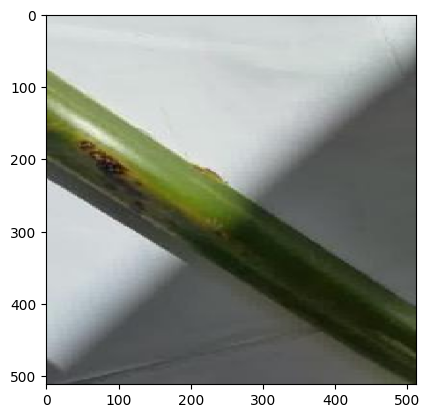

In [60]:
#Input image
test_image = image.load_img('/content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/Date Palm/Copy of Copy of brownspots-105.jpg',target_size=(512,512))

#For show image
plt.imshow(test_image)
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image,axis=0)

# Result array
result = savedModel.predict(test_image)
print(result)

#Mapping result array with the main name list
i=0
for i in range(len(result[0])):
  if(result[0][i]==1):
    print(list_[i])
    break


1/1 [==============================] - 0s 258ms/step
[[0.18906146 0.15201347 0.18402421 0.22396937 0.25093153]]


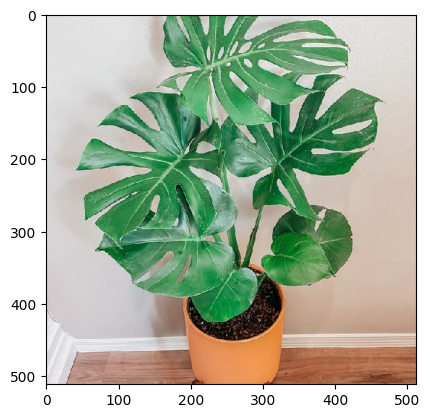

In [61]:
#Input image
test_image = image.load_img('/content/gdrive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model/Monstera deliciosa/MONSTERA_DELICIOSA_106.jpg',target_size=(512,512))

#For show image
plt.imshow(test_image)
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image,axis=0)

# Result array
result = savedModel.predict(test_image)
print(result)

#Mapping result array with the main name list
i=0
for i in range(len(result[0])):
  if(result[0][i]==1):
    print(list_[i])
    break


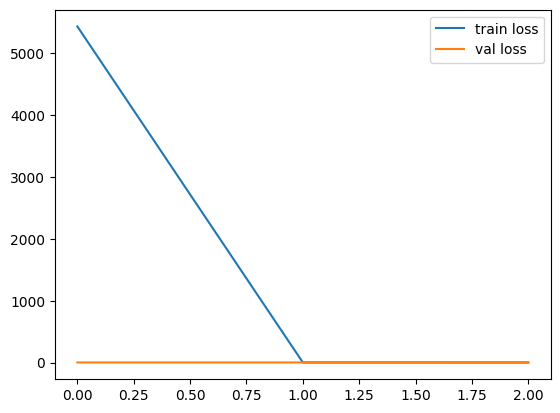

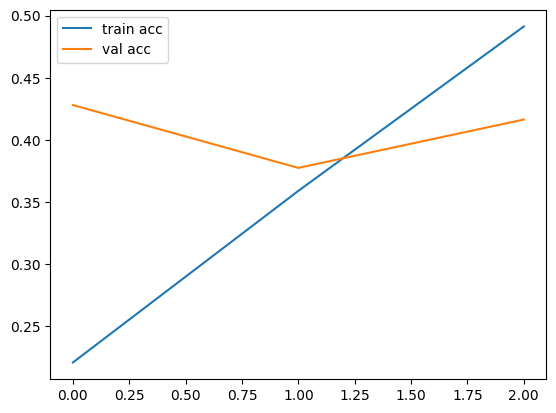

<Figure size 640x480 with 0 Axes>

In [65]:
import matplotlib.pyplot as plt
# plot the loss
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(hist.history['accuracy'], label='train acc')
plt.plot(hist.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')